<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/08_Tree_Based_Algorithms_and_Ensemble_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tree-Based Algorithms and Ensemble Methods**

This notebook covers:

1. Introduction to Decision Trees
2. Random Forests and Bagging
3. Gradient Boosting Machines (GBMs)
4. Hyperparameter Tuning for Trees and Ensembles
5. Comparing Ensemble Methods

# **1. Introduction to Decision Trees**

A **decision tree** is a recursive, hierarchical model that classifies (or regresses) data by successively partitioning the feature space. Each internal node applies a binary decision rule on a feature; each leaf node holds a class prediction.

## **1.1 How Trees are Built**

At each split, the algorithm selects the feature and threshold that best **increases purity** — the degree to which a node contains a single class. The default criterion in scikit-learn is **Gini impurity**:

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

- Gini = 0 → perfectly pure node (only one class)  
- Gini = 0.5 → maximally impure (equal mix of classes)

**Entropy** is the alternative splitting criterion, borrowed from information theory.

## **1.2 Tree Anatomy**

| Node Type | Description |
|---|---|
| **Root node** | First split; all training samples present |
| **Internal node** | Intermediate split; defined by a feature and threshold |
| **Leaf (terminal) node** | No further splits; final class prediction |

## **1.3 Key Hyperparameters**

| Parameter | Effect |
|---|---|
| `max_depth` | Limits tree depth → controls overfitting |
| `min_samples_split` | Minimum samples required to attempt a split |
| `min_samples_leaf` | Minimum samples required at each leaf |
| `max_features` | Number of features to consider at each split |
| `min_impurity_decrease` | Minimum impurity reduction required to split |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024
)

# Decision Tree with default parameters
clf = DecisionTreeClassifier(random_state=2024)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.4f}")

report_df = pd.DataFrame(
    classification_report(y_test, y_pred, output_dict=True)
).transpose()
print("\nClassification Report:")
print(report_df.round(3).to_string())


Decision Tree Accuracy: 0.8667

Classification Report:
              precision  recall  f1-score  support
0                 1.000   1.000     1.000   18.000
1                 0.714   0.833     0.769   12.000
2                 0.846   0.733     0.786   15.000
accuracy          0.867   0.867     0.867    0.867
macro avg         0.853   0.856     0.852   45.000
weighted avg      0.873   0.867     0.867   45.000


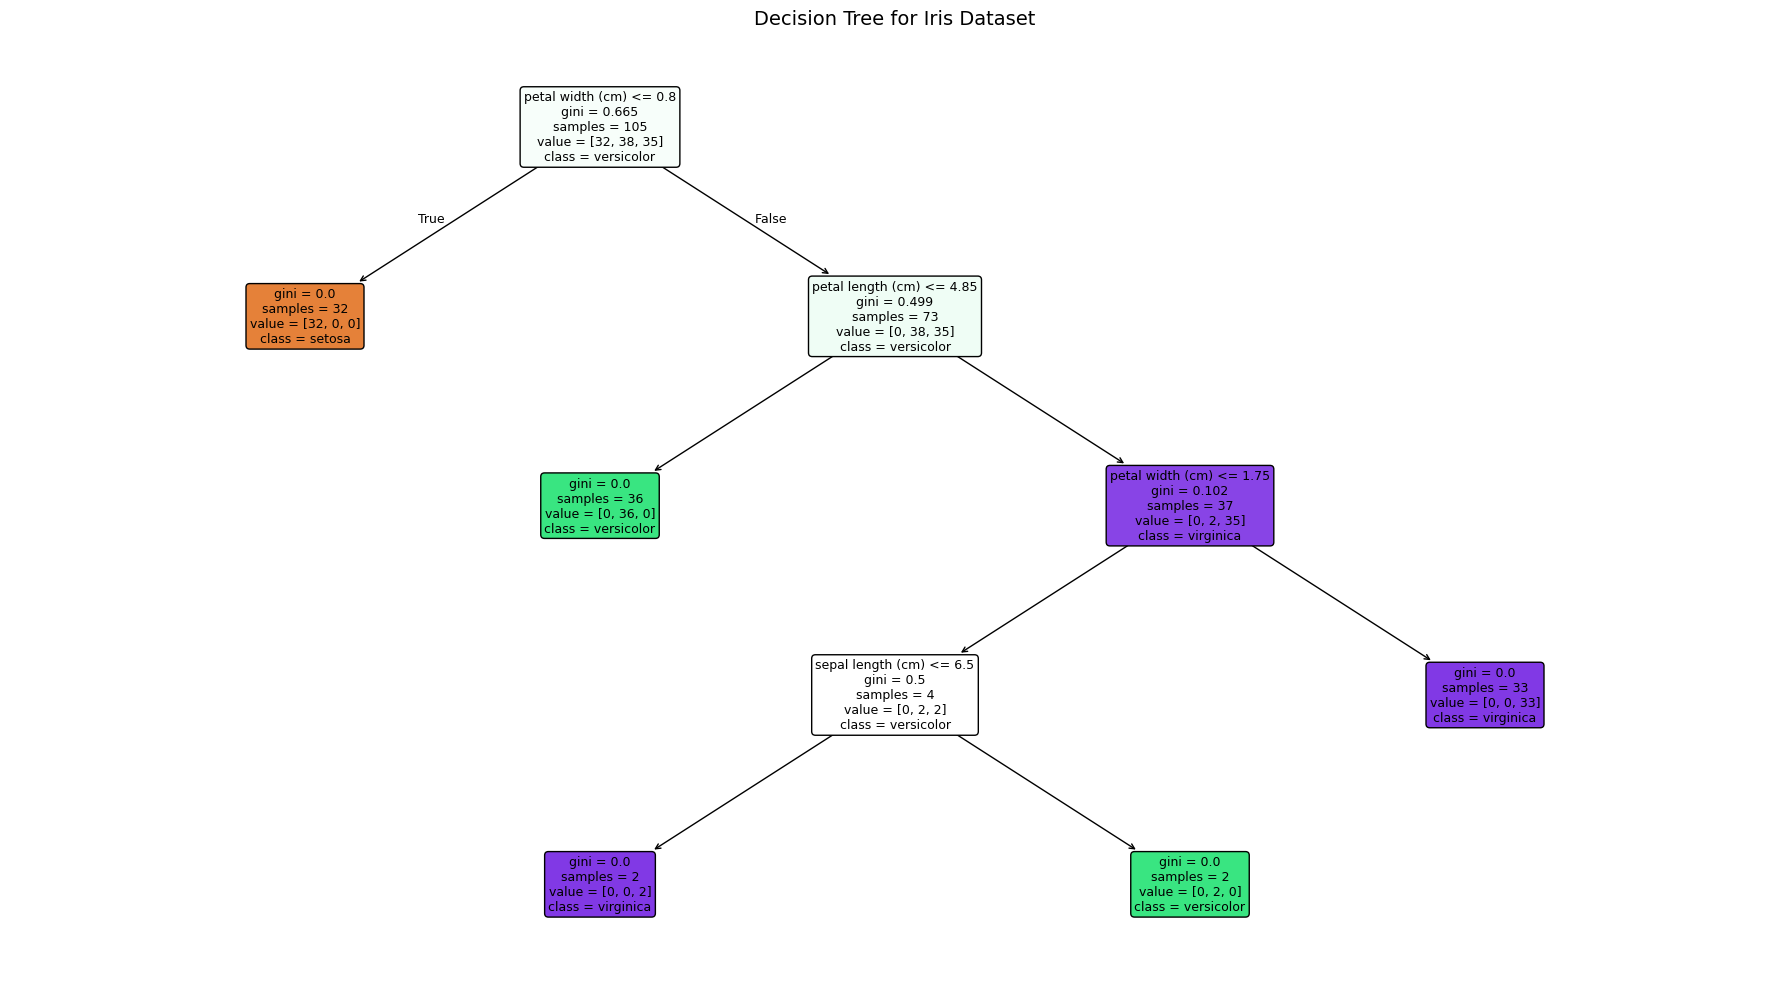

Tree Depth   : 4
Leaf Nodes   : 5
Features Used: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [2]:
# Visualize the decision tree
plt.figure(figsize=(18, 10))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree for Iris Dataset", fontsize=14)
plt.tight_layout()
plt.show()

print("Tree Depth   :", clf.get_depth())
print("Leaf Nodes   :", clf.get_n_leaves())
print("Features Used:", iris.feature_names)


# **2. Random Forests and Bagging**

A single decision tree is interpretable but prone to **overfitting** — it can perfectly memorize training data while failing on new observations. **Random forests** solve this with two innovations:

## **2.1 Bootstrap Aggregating (Bagging)**

Each tree is trained on a **bootstrap sample** — a random subset of the training data drawn *with replacement*. This introduces diversity across trees, so each tree captures slightly different patterns.

$$\hat{y}_{\text{RF}} = \text{majority\_vote}\left(\hat{y}^{(1)}, \hat{y}^{(2)}, \ldots, \hat{y}^{(B)}\right)$$

## **2.2 Feature Randomization**

At each split, only a **random subset of features** is considered (typically $\sqrt{p}$ for classification). This decorrelates the trees, preventing them all from relying on the same dominant features.

## **2.3 Why Ensembles Work**

- **Bias-variance trade-off**: Individual trees have low bias but high variance. Averaging many diverse trees reduces variance dramatically while keeping bias low.
- **Feature importance**: The aggregated reduction in Gini impurity across all trees provides a natural measure of feature importance.

## **2.4 Key Hyperparameters**

| Parameter | Effect |
|---|---|
| `n_estimators` | Number of trees — more trees = more stable predictions |
| `max_features` | Features per split — lower = more decorrelated trees |
| `max_depth` | Per-tree depth — limits individual tree complexity |

In [3]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest with 100 trees
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Single Decision Tree Accuracy : {accuracy:.4f}")
print(f"Random Forest Accuracy        : {acc_rf:.4f}")
print(f"Improvement                   : +{(acc_rf - accuracy)*100:.2f}%")


Single Decision Tree Accuracy : 0.8667
Random Forest Accuracy        : 0.9111
Improvement                   : +4.44%


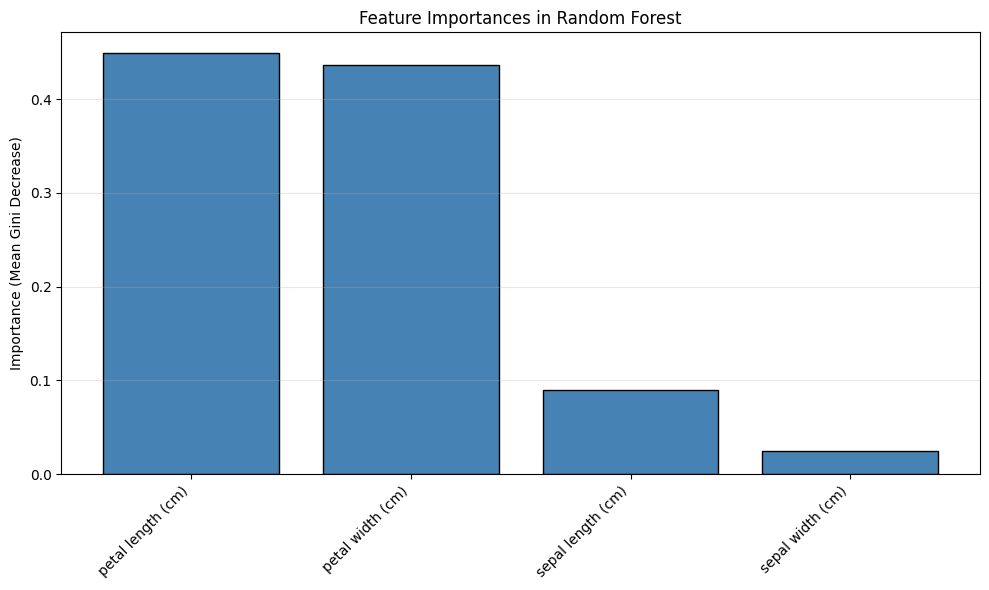

Feature Importance Ranking:
  petal length (cm)         : 0.4489
  petal width (cm)          : 0.4360
  sepal length (cm)         : 0.0901
  sepal width (cm)          : 0.0251


In [4]:
# Feature importance plot
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances in Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align='center', color='steelblue', edgecolor='k')
plt.xticks(range(X.shape[1]),
           [iris.feature_names[i] for i in indices], rotation=45, ha='right')
plt.ylabel("Importance (Mean Gini Decrease)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
for i in indices:
    print(f"  {iris.feature_names[i]:<25} : {importances[i]:.4f}")


# **3. Gradient Boosting Machines (GBMs)**

While random forests train trees **in parallel** on independent bootstrap samples, **gradient boosting** trains trees **sequentially** — each new tree corrects the **residual errors** of the previous ensemble.

## **3.1 The Boosting Idea**

At each iteration $m$, a new tree $h_m$ is fit to the residuals (negative gradient of the loss):

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Where $\eta$ is the **learning rate** — a shrinkage factor that controls the contribution of each tree.

## **3.2 Key Hyperparameters**

| Parameter | Effect |
|---|---|
| `n_estimators` | Number of boosting rounds (trees) |
| `learning_rate` | Shrinkage per tree — lower rates need more trees |
| `max_depth` | Tree depth per round — typically shallow (3–5) |
| `subsample` | Fraction of samples per tree — introduces stochasticity |

## **3.3 Bias-Variance Perspective**

- Random forests primarily **reduce variance** (averaging diverse trees)  
- GBMs primarily **reduce bias** (correcting systematic errors iteratively)

## **3.4 Overfitting Control**

- **Early stopping**: halt boosting when validation performance stops improving  
- **Validation curves**: track train vs. test performance across `n_estimators` to identify the optimal stopping point

In [5]:
from sklearn.ensemble import GradientBoostingClassifier

# GBM Classifier
gbm_clf = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.2,
    random_state=2024
)
gbm_clf.fit(X_train, y_train)
y_pred_gbm = gbm_clf.predict(X_test)

acc_gbm = accuracy_score(y_test, y_pred_gbm)
print(f"Single Decision Tree Accuracy : {accuracy:.4f}")
print(f"Random Forest Accuracy        : {acc_rf:.4f}")
print(f"GBM Accuracy                  : {acc_gbm:.4f}")


Single Decision Tree Accuracy : 0.8667
Random Forest Accuracy        : 0.9111
GBM Accuracy                  : 0.8667


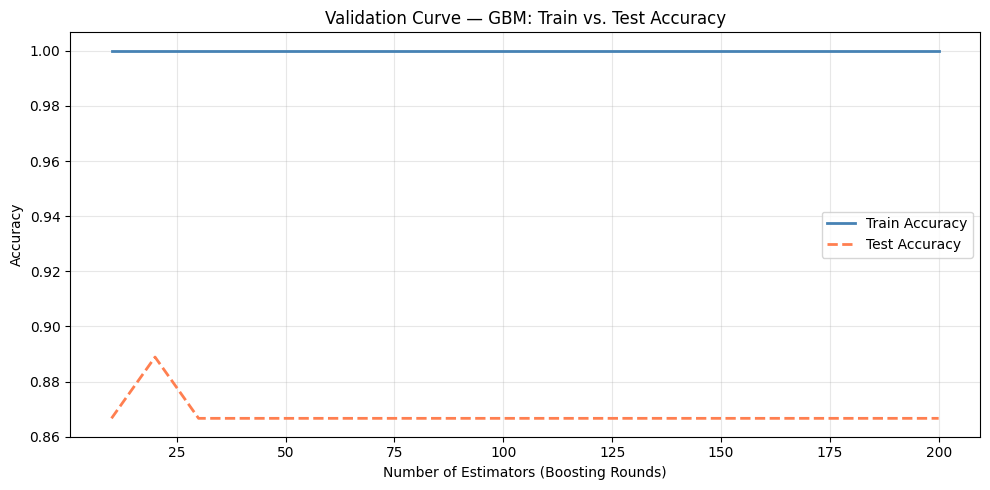

In [6]:
# Validation curve: track train vs test accuracy across n_estimators
train_scores = []
test_scores  = []
n_est_range  = range(10, 201, 10)

for n in n_est_range:
    gbm_temp = GradientBoostingClassifier(
        n_estimators=n, learning_rate=0.2, random_state=2024
    )
    gbm_temp.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, gbm_temp.predict(X_train)))
    test_scores.append(accuracy_score(y_test, gbm_temp.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(n_est_range, train_scores, label='Train Accuracy', color='steelblue', linewidth=2)
plt.plot(n_est_range, test_scores,  label='Test Accuracy',  color='coral',     linewidth=2, linestyle='--')
plt.xlabel('Number of Estimators (Boosting Rounds)')
plt.ylabel('Accuracy')
plt.title('Validation Curve — GBM: Train vs. Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **4. Hyperparameter Tuning for Trees and Ensembles**

Tree-based models have multiple interacting hyperparameters. Systematic tuning via **GridSearchCV** or **RandomizedSearchCV** is essential to find configurations that generalize well.

## **4.1 GridSearchCV vs. RandomizedSearchCV**

| Method | Approach | Best For |
|---|---|---|
| `GridSearchCV` | Exhaustive: tests all combinations | Small search spaces |
| `RandomizedSearchCV` | Samples a fixed number at random | Large search spaces |

Both use **k-fold cross-validation** to estimate performance, ensuring that the chosen parameters generalize rather than fitting the test set.

## **4.2 Heatmap Visualization**

After grid search, plotting a heatmap of cross-validation scores against pairs of hyperparameters (e.g., `max_depth` vs. `n_estimators`) reveals interaction effects and helps identify regions of stable performance.

In [7]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for GBM
param_grid = {
    'n_estimators' : [50, 100, 150],
    'max_depth'    : [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=2024),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV Score   : {grid_search.best_score_:.4f}")

best_gbm = grid_search.best_estimator_
y_pred_best_gbm = best_gbm.predict(X_test)
print(f"Test Accuracy   : {accuracy_score(y_test, y_pred_best_gbm):.4f}")


Best Parameters : {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 50}
Best CV Score   : 0.9810
Test Accuracy   : 0.8667


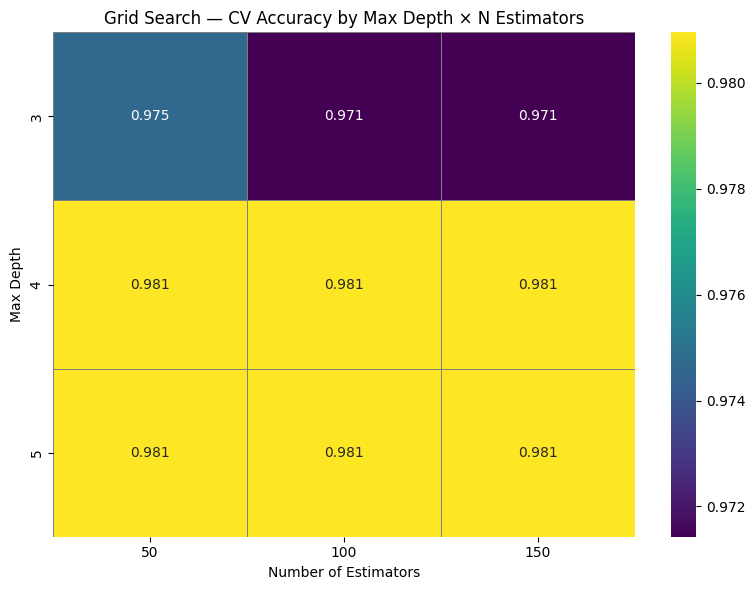

In [8]:
# Heatmap of cross-validation accuracy
results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='viridis',
            linewidths=0.5, linecolor='gray')
plt.title('Grid Search — CV Accuracy by Max Depth × N Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Max Depth')
plt.tight_layout()
plt.show()


# **5. Comparing Ensemble Methods**

The chapter concludes by comparing three ensemble strategies on the same dataset:

## **5.1 The Three Ensemble Paradigms**

| Method | Strategy | Reduces | Best For |
|---|---|---|---|
| **Bagging** (Random Forest) | Parallel trees on bootstrap samples | Variance | Noisy, high-dimensional data |
| **Boosting** (GBM) | Sequential trees correcting residuals | Bias | Structured, tabular data |
| **Stacking** | Meta-model combines base model predictions | Both | Diverse model families |

## **5.2 Stacking**

`StackingClassifier` combines predictions from multiple base models (e.g., Random Forest + GBM) by feeding them as features into a **meta-model** (typically Logistic Regression). Cross-validation is used internally to prevent data leakage between the base and meta layers.

$$\hat{y}_{\text{stack}} = g\left(\hat{y}_{\text{RF}}, \hat{y}_{\text{GBM}}\right)$$

Where $g$ is the meta-learner (e.g., LogisticRegression).

In [9]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Base models
rf_final  = RandomForestClassifier(n_estimators=100, random_state=2024)
gb_final  = GradientBoostingClassifier(n_estimators=100, random_state=2024)

# Stacking classifier
stacking_clf = StackingClassifier(
    estimators=[('rf', rf_final), ('gb', gb_final)],
    final_estimator=LogisticRegression(),
    cv=5
)

# Train all three
rf_final.fit(X_train, y_train)
gb_final.fit(X_train, y_train)
stacking_clf.fit(X_train, y_train)

# Evaluate
acc_rf_f  = accuracy_score(y_test, rf_final.predict(X_test))
acc_gb_f  = accuracy_score(y_test, gb_final.predict(X_test))
acc_st_f  = accuracy_score(y_test, stacking_clf.predict(X_test))

print(f"Random Forest Accuracy : {acc_rf_f:.4f}")
print(f"Gradient Boosting Acc  : {acc_gb_f:.4f}")
print(f"Stacking Accuracy      : {acc_st_f:.4f}")


Random Forest Accuracy : 0.9111
Gradient Boosting Acc  : 0.8667
Stacking Accuracy      : 0.8667


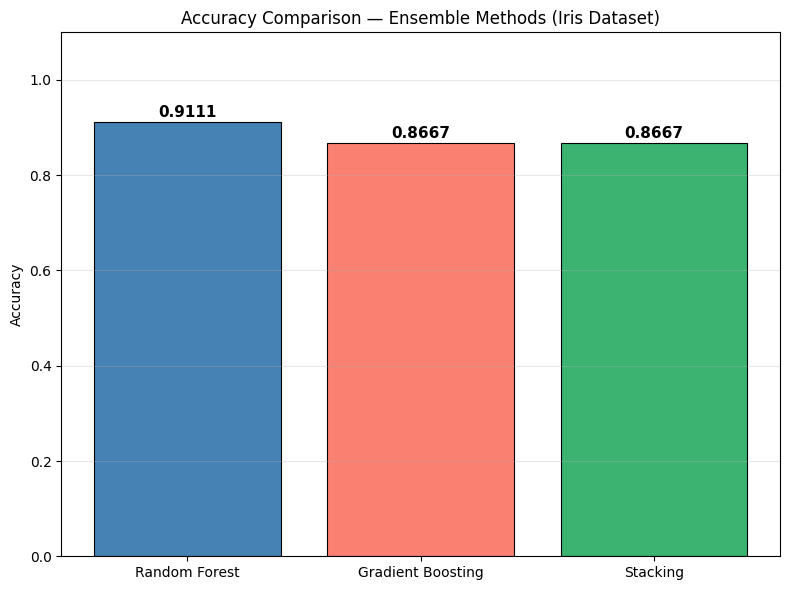

In [10]:
# Bar chart comparison
methods    = ['Random Forest', 'Gradient Boosting', 'Stacking']
accuracies = [acc_rf_f, acc_gb_f, acc_st_f]
colors     = ['steelblue', 'salmon', 'mediumseagreen']

plt.figure(figsize=(8, 6))
bars = plt.bar(methods, accuracies, color=colors, edgecolor='k', linewidth=0.8)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison — Ensemble Methods (Iris Dataset)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
